In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("C:/Users/12sha/OneDrive/Desktop/MP_6thSem/data/updated_data.csv")

In [4]:
df.head()

,time,temperature,vibration,sound,anomaly,temp_roll_mean,vib_roll_mean,sound_roll_mean,temp_roll_std,vib_roll_std,sound_roll_std
0,49,29.188947,-0.015172,46.564832,0.0,29.920146,0.108273,45.009719,0.460476,0.722081,1.487562
1,50,30.241770,-0.413303,47.097820,0.0,29.919964,0.098604,45.059196,0.460345,0.725829,1.515351
2,51,29.909556,-0.376216,44.991851,0.0,29.919708,0.083806,45.039189,0.460347,0.727854,1.509373
3,52,29.759116,-0.873411,46.083147,0.0,29.908841,0.058425,45.056855,0.457532,0.738802,1.516445
4,53,30.409837,-1.086053,46.305419,0.0,29.902197,0.018301,45.070758,0.447488,0.745496,1.524786


In [4]:
features = ["temperature", "vibration", "sound", "temp_roll_mean", "vib_roll_mean", "sound_roll_mean",
            "temp_roll_std", "vib_roll_std", "sound_roll_std"]
X = df[features]

In [6]:
X

,temperature,vibration,sound,temp_roll_mean,vib_roll_mean,sound_roll_mean,temp_roll_std,vib_roll_std,sound_roll_std
0,29.188947,-0.015172,46.564832,29.920146,0.108273,45.009719,0.460476,0.722081,1.487562
1,30.241770,-0.413303,47.097820,29.919964,0.098604,45.059196,0.460345,0.725829,1.515351
2,29.909556,-0.376216,44.991851,29.919708,0.083806,45.039189,0.460347,0.727854,1.509373
3,29.759116,-0.873411,46.083147,29.908841,0.058425,45.056855,0.457532,0.738802,1.516445
4,30.409837,-1.086053,46.305419,29.902197,0.018301,45.070758,0.447488,0.745496,1.524786
...,...,...,...,...,...,...,...,...,...
19946,72.581634,1.573947,49.331767,72.300908,2.515877,52.432891,0.693027,0.779748,1.629484
19947,73.317383,1.735982,52.006080,72.312093,2.480362,52.450743,0.704967,0.773883,1.619593
19948,71.532026,1.762616,51.713412,72.297771,2.451084,52.416227,0.713515,0.772768,1.616485
19949,74.226288,2.203738,50.263507,72.331737,2.429215,52.410367,0.763378,0.763754,1.623878


In [5]:
train_size = int(0.7 * len(df))

In [6]:
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = df["anomaly"].iloc[train_size:]

In [7]:
scaler = StandardScaler()

In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = IsolationForest(
    n_estimators = 100,
    contamination= 0.05,
    random_state = 42
)

In [10]:
model.fit(X_train_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
# Convert : 1-> normal, -1 -> anomaly
y_pred = np.where(y_pred == -1, 1, 0)

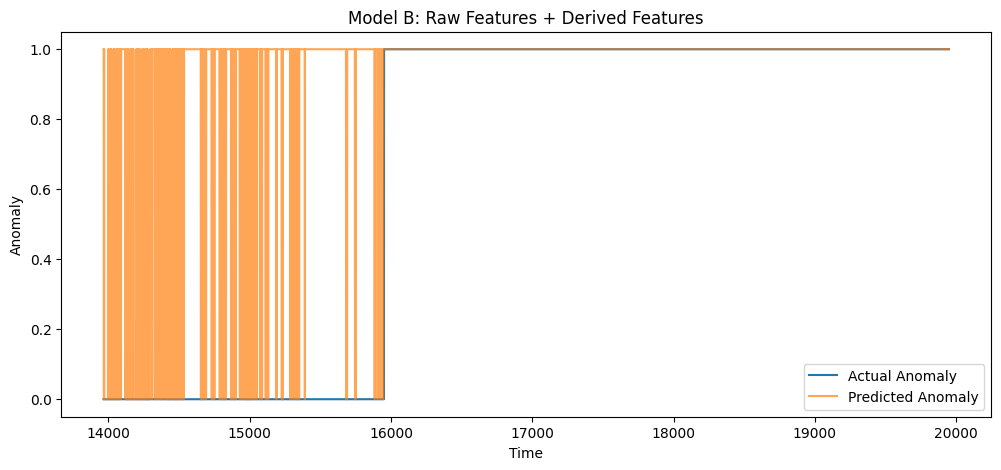

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[train_size:], y_test, label= "Actual Anomaly")
plt.plot(df.index[train_size:], y_pred, label = "Predicted Anomaly", alpha=0.7)
plt.legend()
plt.title("Model B: Raw Features + Derived Features")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.show()

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.22      0.36      1986
         1.0       0.72      1.00      0.84      4000

    accuracy                           0.74      5986
   macro avg       0.86      0.61      0.60      5986
weighted avg       0.81      0.74      0.68      5986



In [15]:
scores = model.decision_function(X_test_scaled)
smooth_scores = pd.Series(scores).rolling(window=20).mean()
green_threshold = np.percentile(smooth_scores, 60)
yellow_threshold = np.percentile(smooth_scores, 20)


In [16]:
scores = model.decision_function(X_test_scaled)
# Smooth
smooth_scores = pd.Series(scores).rolling(window= 10).mean().dropna()
# Reseting index after dropna
smooth_scores = smooth_scores.reset_index(drop=True)

In [17]:
# thresholds
green_th = np.percentile(smooth_scores, 60)
yellow_th = np.percentile(smooth_scores, 20)

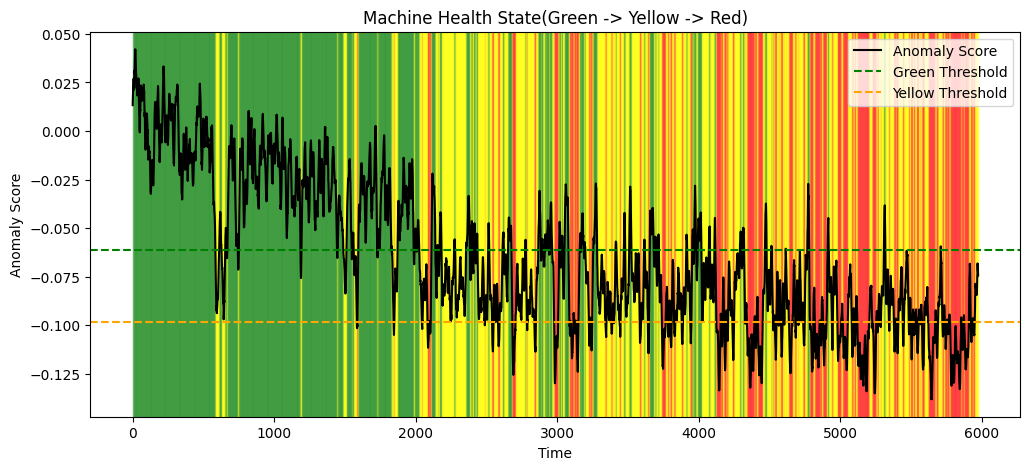

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(smooth_scores, color = "black", label = "Anomaly Score")
# Background coloring
for i in range(len(smooth_scores)-1):
    if smooth_scores[i] > green_th:
        plt.axvspan(i, i+1, color = "green", alpha= 0.1)
    elif smooth_scores[i] > yellow_th:
        plt.axvspan(i, i+1, color= 'yellow', alpha= 0.15)
    else:
        plt.axvspan(i, i+1, color= 'red', alpha = 0.1)
# Threshold lines
plt.axhline(green_th, color = 'green', linestyle= '--', label= 'Green Threshold')
plt.axhline(yellow_th, color = 'orange', linestyle= '--', label= 'Yellow Threshold')

plt.title("Machine Health State(Green -> Yellow -> Red)")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [26]:
model1 = IsolationForest(
    n_estimators = 100,
    contamination = 0.03,
    random_state = 42 
)

In [27]:
model1.fit(X_train_scaled)

IsolationForest(contamination=0.03, random_state=42)

In [28]:
y_pred = model1.predict(X_test_scaled)

In [29]:
# Convert: 1 -> normal, -1 -> anomaly
y_pred = np.where(y_pred == -1, 1, 0)

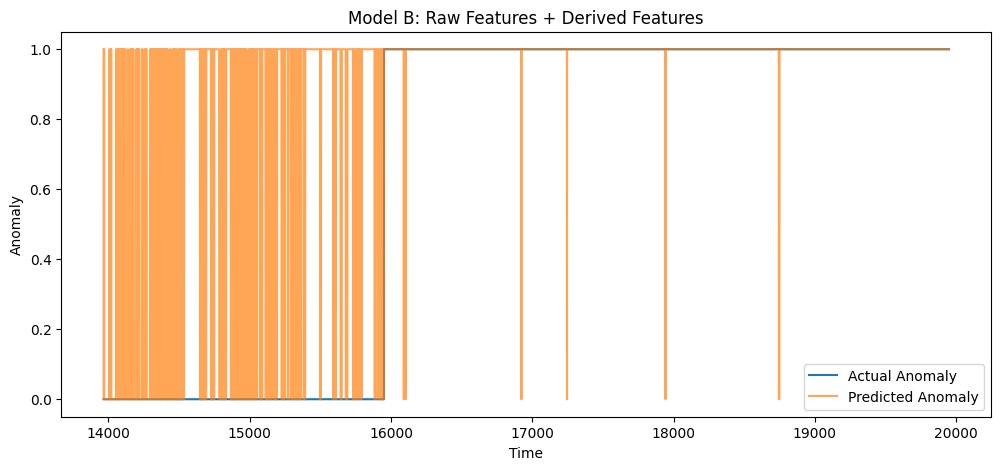

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[train_size:], y_test, label= "Actual Anomaly")
plt.plot(df.index[train_size:], y_pred, label= "Predicted Anomaly", alpha= 0.7)
plt.legend()
plt.title("Model B: Raw Features + Derived Features")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.35      0.52      1986
         1.0       0.76      1.00      0.86      4000

    accuracy                           0.78      5986
   macro avg       0.87      0.68      0.69      5986
weighted avg       0.83      0.78      0.75      5986



In [32]:
scores = model1.decision_function(X_test_scaled)
smooth_scores = pd.Series(scores).rolling(window= 15).mean()

In [33]:
green_th = np.percentile(smooth_scores.dropna(), 60)
yellow_th = np.percentile(smooth_scores.dropna(), 20)

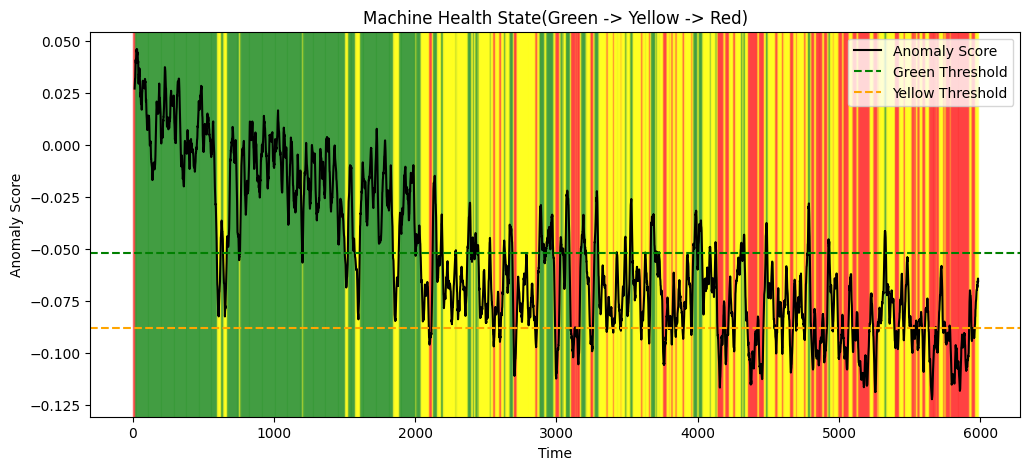

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(smooth_scores, color = "black", label = "Anomaly Score")
# Background coloring
for i in range(len(smooth_scores)-1):
    if smooth_scores[i] > green_th:
        plt.axvspan(i, i+1, color = "green", alpha= 0.1)
    elif smooth_scores[i] > yellow_th:
        plt.axvspan(i, i+1, color= 'yellow', alpha= 0.15)
    else:
        plt.axvspan(i, i+1, color= 'red', alpha = 0.1)
# Threshold lines
plt.axhline(green_th, color = 'green', linestyle= '--', label= 'Green Threshold')
plt.axhline(yellow_th, color = 'orange', linestyle= '--', label= 'Yellow Threshold')

plt.title("Machine Health State(Green -> Yellow -> Red)")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [24]:
print(y_test.value_counts())

anomaly
1.0    4000
0.0    1986
Name: count, dtype: int64


In [25]:
import joblib

In [ ]:
joblib.dump(model1, "C:/Users/12sha/OneDrive/Desktop/MP_6thSem/model/I_Tree.pkl")

['C:/Users/12sha/OneDrive/Desktop/MP_6thSem/model/I_Tree.pkl']

In [36]:
joblib.dump(scaler, "C:/Users/12sha/OneDrive/Desktop/MP_6thSem/model/scaler.pkl")

['C:/Users/12sha/OneDrive/Desktop/MP_6thSem/model/scaler.pkl']